# 09 · Deep Learning from Scratch (NumPy) — Backprop, Adam & Forecasting  (stretch)

## Part 9 — Deep Learning from Scratch (NumPy)  · *stretch*

Part 5 reframed forecasting as supervised learning and used gradient-boosted trees. Neural
networks attack the *same* (X, y) table with a different function class — stacked linear layers
with nonlinear activations, trained by gradient descent. Here we build one **from scratch in
NumPy** — forward pass, **backpropagation**, and the **Adam** optimizer — so nothing is hidden.

> **Why from scratch?** This machine's **Smart App Control blocks PyTorch** (its DLLs are
> unsigned), so `neuralforecast`'s NHITS/LSTM can't run here. Hand-building the network is the
> honest path — and it exposes the mechanics a library call hides. The architecture choices that a
> real NHITS/LSTM/TFT would add are discussed at the end.

| # | piece | idea |
|---|---|---|
| 2 | **Architecture** | layers, weights, ReLU — a flexible function approximator |
| 3 | **Learning** | MSE loss · backprop (chain rule) · Adam gradient descent |
| 4–5 | **Forecasting CO₂** | difference (stationarity!) → train → recursive multi-step |
| 6 | **Scoreboard** | honest comparison vs LightGBM / Holt-Winters / SARIMA |
| 7 | **When DL wins** | why a small net loses here, and where deep models dominate |

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
ROOT = pathlib.Path.cwd()
ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from src import data, eda
eda.set_style()
pd.set_option("display.width", 120, "display.max_columns", 30)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

import lightgbm as lgb
from src import neuralnet as nn, ml_forecast as mlf, forecasting as fc
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.datasets import co2

co2m = co2.load_pandas().data["co2"].resample("MS").mean().interpolate()
H = 24
tr, te = co2m[:-H], co2m[-H:]
print("CO2 train:", len(tr), "months | test:", H)


setup ok | numpy 2.1.3 | pandas 2.3.3


CO2 train: 502 months | test: 24


### 2. Anatomy of the network

An MLP maps inputs to output through **layers**. Each layer computes `a = activation(a_prev · W + b)`:
a linear mix of the previous layer, then a nonlinearity (**ReLU**: `max(0, z)`) that lets the net
bend. Stack a few and it can approximate almost any function. Two practical musts:

- **Standardize inputs** (zero mean, unit variance) — otherwise gradients are lopsided and training
  stalls. Our `MLPRegressor` does this internally.
- **He initialisation** of weights (variance `2/fan_in`) keeps signals from vanishing/exploding.

The whole network is just matrices `W` and vectors `b` — let's count them:

In [2]:
net0 = nn.MLPRegressor(hidden=(64, 32))
net0._init_params(n_in=20)
nparams = sum(w.size for w in net0.W) + sum(b.size for b in net0.b)
print("architecture: 20 inputs -> 64 -> 32 -> 1 output  (ReLU hidden, linear output)")
print("layer weight shapes:", [w.shape for w in net0.W])
print("trainable parameters:", nparams)

architecture: 20 inputs -> 64 -> 32 -> 1 output  (ReLU hidden, linear output)
layer weight shapes: [(20, 64), (64, 32), (32, 1)]
trainable parameters: 3457


### 3. How it learns — backprop + Adam

Training minimises the **mean squared error** between predictions and targets:

1. **Forward pass** — push X through the layers to get ŷ.
2. **Loss** — `MSE = mean((ŷ − y)²)`.
3. **Backpropagation** — apply the chain rule layer by layer to get `∂Loss/∂W`, `∂Loss/∂b`.
4. **Adam update** — a smart gradient-descent step (per-parameter adaptive learning rate with
   momentum) that converges far faster than plain SGD.

Proof the engine is correct: train it on a **known nonlinear function** `sin(x₁) + x₂²` and watch
the loss collapse and R² hit ~1.

R^2 on sin(x1)+x2^2 = 1.000   (1.0 = perfect -> backprop works)


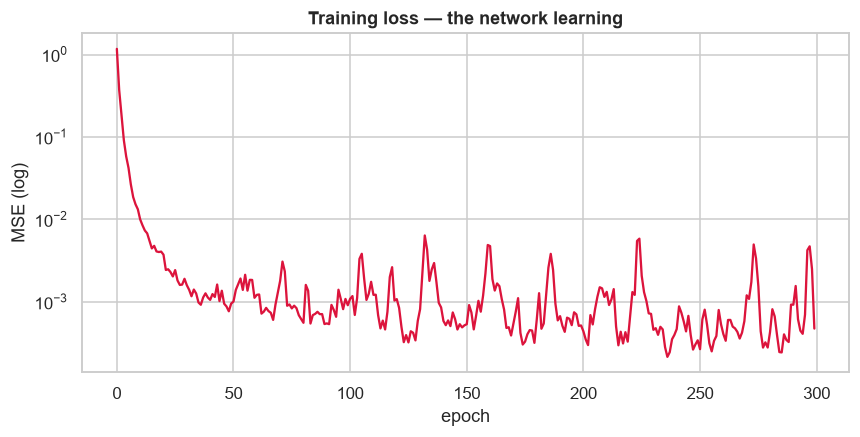

In [3]:
from sklearn.metrics import r2_score
rng = np.random.default_rng(0); X = rng.uniform(-3, 3, (800, 2)); y = np.sin(X[:,0]) + X[:,1]**2
demo = nn.MLPRegressor(hidden=(32, 16), epochs=300, lr=0.01, seed=0).fit(X, y)
print("R^2 on sin(x1)+x2^2 = %.3f   (1.0 = perfect -> backprop works)" % r2_score(y, demo.predict(X)))
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(demo.loss_history_, color="crimson"); ax.set_yscale("log")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE (log)"); ax.set_title("Training loss — the network learning")
eda.savefig(fig, "p9_loss_curve.png"); plt.show()

### 4–5. Forecasting CO₂ — same discipline as Part 5

A neural net is no more able to **extrapolate a trend** than a tree, so we apply the same fix:
forecast the **differenced** (stationary) series with the leakage-safe lag/rolling/calendar
features from Part 5, then reconstruct the level. The net plugs straight into the same
`recursive_forecast` driver.

C:\Users\parth\practice-eda\sp500-shiller\src\eda.py:25: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.savefig(FIGS / name, bbox_inches="tight", dpi=130)
C:\Users\parth\practice-eda\sp500-shiller\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


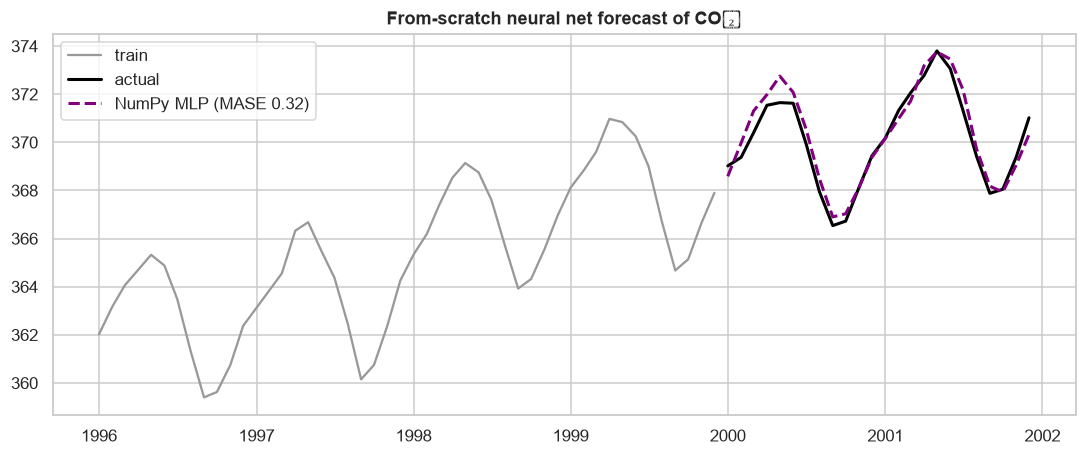

MLP-diff MASE = 0.320  (naive ~1.86, so the net DID learn the structure)


In [4]:
d = tr.diff().dropna()
sup = mlf.make_supervised(d, n_lags=12); cols = mlf.feature_cols(sup)
net = nn.MLPRegressor(hidden=(64, 32), epochs=600, lr=0.01, batch=32, l2=1e-4, seed=0)
net.fit(sup[cols].values, sup["y"].values)
pred_mlp = mlf.reconstruct_from_diff(mlf.recursive_forecast(net, d, H, cols), tr.iloc[-1])
mase_mlp = fc.forecast_metrics(te.values, pred_mlp.values, tr.values, 12)["MASE"]
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(tr.index[-48:], tr.values[-48:], color="0.6", label="train")
ax.plot(te.index, te.values, color="black", lw=2, label="actual")
ax.plot(pred_mlp.index, pred_mlp.values, "--", color="purple", lw=2, label=f"NumPy MLP (MASE {mase_mlp:.2f})")
ax.set_title("From-scratch neural net forecast of CO₂"); ax.legend()
eda.savefig(fig, "p9_mlp_forecast.png"); plt.show()
print("MLP-diff MASE = %.3f  (naive ~1.86, so the net DID learn the structure)" % mase_mlp)

### 6. Honest scoreboard — does the neural net win?

In [5]:
lgbm = lgb.LGBMRegressor(n_estimators=300, num_leaves=31, learning_rate=0.05,
                         min_child_samples=10, random_state=0, verbose=-1).fit(sup[cols], sup["y"])
pred_lgbm = mlf.reconstruct_from_diff(mlf.recursive_forecast(lgbm, d, H, cols), tr.iloc[-1])
hw  = ExponentialSmoothing(tr, trend="add", seasonal="add", seasonal_periods=12).fit().forecast(H).values
sar = SARIMAX(tr, order=(1,1,1), seasonal_order=(1,1,1,12)).fit(disp=False).forecast(H).values
board = fc.compare_models(te, {"NumPy-MLP": pred_mlp.values, "LGBM-diff": pred_lgbm.values,
                               "Holt-Winters": hw, "SARIMA": sar}, tr, m=12)
print(board[["MAE","RMSE","MASE"]].to_string())

                 MAE    RMSE    MASE
Holt-Winters  0.2357  0.3070  0.1815
LGBM-diff     0.2931  0.3496  0.2257
SARIMA        0.3338  0.4095  0.2570
NumPy-MLP     0.4152  0.4984  0.3198


The honest verdict, and the whole point of the part: a **from-scratch net underperforms** the
tuned classical and tree models on this **small, single, clean** series. It learned (it crushes
the naive baseline) but it has ~480 points and thousands of parameters — too little data for its
flexibility to pay off. This is Part 5's lesson, sharpened: *more capacity is not more accuracy.*

### 7. So when *does* deep learning win?

Not on one tidy series — on **scale and structure** the net can exploit:

- **Many related series at once** (a *global* model): train one network across thousands of series
  so it borrows strength across them — this is where **NHITS, DeepAR, TFT** dominate classical
  per-series models.
- **Rich covariates & long context**: holidays, prices, weather, long seasonal memory.
- **Sequence structure**: **RNN/LSTM/GRU** carry hidden state across time; **Transformers**
  (PatchTST, Informer) attend over long horizons. Our MLP has none of this memory.
- **Foundation models** (TimeGPT, Chronos, TimesFM): pretrained on millions of series, forecast
  **zero-shot**.

The real implementations live in **`neuralforecast` / Darts / GluonTS** on PyTorch — which Smart
App Control blocks here. The *method* is identical to what we built; the libraries add the
architectures, GPU training, and scale. The decision rule from Part 5 stands: **baseline →
classical → trees → deep**, climbing only when the data justifies it.

### Takeaways

- A neural net is a stacked linear-plus-ReLU function approximator trained by **backprop + Adam** —
  we built it in ~80 lines of NumPy and it learns arbitrary functions (R² ≈ 1 on a sanity task).
- It attacks the **same supervised reframing** as Part 5 and needs the **same stationarity
  discipline** (difference the trend) — capacity doesn't exempt it from the basics.
- On a **small single series it loses** to tuned Holt-Winters / LightGBM — neural nets are
  **data-hungry**; their edge is **many series, covariates, long context, and scale**.
- Production deep forecasting (NHITS/LSTM/TFT, foundation models) is the same idea at scale via
  PyTorch-based libraries — unavailable on this machine due to Smart App Control, but the mechanics
  are exactly what we implemented.

*This rounds out the ML/DL arc (Parts 5 & 9) of the project. Everything remains reproducible on the
pinned Python 3.12 venv; the deep-learning math here runs with nothing but NumPy.*